# Análisis Visual de Ventas Minoristas — *Retail Sales Dataset*

## Grupo 2
**Integrantes:** Ángel Espín · Carlos Ramírez
**Tipo de trabajo:** Equipo de dos personas
**Herramienta de visualización:** Tableau (conexión a extracto nativo `.hyper`)
**Fecha:** 2026

---

> ### ⚠️ Cómo usar este cuaderno (léelo primero)
>
> El **entregable real del proyecto es el dashboard de Tableau**. La consigna prohíbe usar
> *backends* personalizados (Node.js, **Python**, etc.) y bases de datos como Postgres/MySQL
> **como parte de la implementación de la visualización**.
>
> Por eso **este cuaderno NO es la visualización**: es la **documentación y la guía** del proyecto.
> Aquí se concentra todo lo que la consigna pide *por escrito* (las cuatro fases) y lo que no se
> puede "escribir" dentro de Tableau (análisis, abstracción de datos y tareas, justificación de
> marcas y canales). En cada fase se indica **en qué parte del dashboard de Tableau** se cumple.
>
> Python se usa aquí **únicamente** para dos cosas legítimas y permitidas:
> 1. **Preprocesar los datos** (limpieza + derivación de atributos) — la consigna recomienda preprocesar.
> 2. **Generar el archivo `retail_sales.hyper`**, que es el **formato de extracto NATIVO de Tableau**.
>    Un `.hyper` **no es** un backend ni una base de datos externa: es el archivo de datos que
>    Tableau usa internamente. Conectarse a un `.hyper` es flujo estándar de Tableau.
>
> **Qué entregar:** el dashboard de Tableau (`.twb`/`.twbx` o enlace a Tableau Public) + esta documentación.
> **Qué NO es parte de la "implementación":** este cuaderno y los scripts de Python (son apoyo).


## Índice

1. [Fase 1 — Descripción General](#fase1)
2. [Fase 2 — Implementación y Documentación](#fase2)
3. [Fase 3 — Abstracción de Datos y Tareas](#fase3)
4. [Fase 4 — Marcas y Canales (decisiones de diseño)](#fase4)
5. [Anexo A — Preprocesamiento y generación del `.hyper` (código Python)](#anexoA)
6. [Anexo B — Análisis exploratorio (gráficos de apoyo)](#anexoB)
7. [Anexo C — Guía paso a paso para construir el dashboard en Tableau](#anexoC)


<a id="fase1"></a>
# Fase 1 — Descripción General

## Objetivo
Implementar un **panel de análisis visual interactivo (dashboard)** en Tableau que permita a la
gerencia de una tienda minorista **explorar sus ventas** desde tres ángulos —tiempo, producto y
cliente— para apoyar decisiones de inventario, marketing y dotación de personal.

*¿Dónde se cumple en Tableau?* En el dashboard final llamado **`Dashboard — Ventas Minoristas 2023`**,
que integra los cinco worksheets descritos en la [Fase 4](#fase4) y el [Anexo C](#anexoC).

## Equipo
**Grupo 2** — trabajo de **dos personas**:

| # | Integrante |
|---|------------|
| 1 | Ángel Espín |
| 2 | Carlos Ramírez |

## Datos
- **Conjunto de datos:** *Retail Sales Dataset* (público, alojado en Kaggle).
- **Enlace:** https://www.kaggle.com/datasets/mohammadtalib786/retail-sales-dataset
- **Fuente de descarga usada (espejo público en GitHub):**
  `https://raw.githubusercontent.com/RISHIshrivas/Retail-Sales-data-analysis/main/retail_sales_dataset.csv`
- **Naturaleza:** datos transaccionales **sintéticos** de una tienda minorista que simulan
  compras reales (ideal para EDA y visualización sin problemas de privacidad).
- **Tamaño:** **1 000 transacciones**, **9 atributos** originales, período principal **año 2023**.
- **Almacenamiento:** local, convertido al extracto nativo de Tableau **`retail_sales.hyper`**.

La descripción detallada del dataset y de cada atributo está en la [Fase 2](#fase2) y la
[Fase 3](#fase3).


<a id="fase2"></a>
# Fase 2 — Implementación y Documentación

## Implementación
- **Herramienta:** **Tableau** (Desktop / Public), una de las herramientas vistas en clase.
- **Origen de datos:** extracto **`.hyper`** (formato nativo de Tableau).
- **Sin backend propio ni base de datos externa:** no se usa Node.js, Python, Postgres ni MySQL
  *dentro de la solución de visualización*. Todo el dato vive en el `.hyper` y toda la lógica visual
  vive en Tableau.

## Título del proyecto
**“Análisis Visual de Ventas Minoristas: patrones temporales, de producto y demográficos (2023)”.**

## Integrantes
Grupo 2 — **Ángel Espín** y **Carlos Ramírez**.

## Descripción del problema y cómo el proyecto lo resuelve
Una tienda minorista registra cada venta (qué se vendió, cuándo, a qué precio y a qué cliente),
pero esos **datos crudos no revelan por sí solos los patrones** que necesita la gerencia:
*¿En qué meses se vende más? ¿Qué categoría aporta más ingresos? ¿Qué perfil de cliente gasta más?*
Responder esto leyendo una tabla de 1 000 filas es inviable y propenso a error.

**Cómo lo resuelve el proyecto:** un dashboard interactivo que **codifica visualmente** las
ventas en cinco vistas complementarias (KPIs, tendencia temporal, comparación por categoría,
perfil demográfico y mapa de calor categoría×mes) con **filtros** por trimestre, género y
categoría. Así la gerencia pasa de *“mirar filas”* a *“ver patrones”* y puede responder sus
preguntas en segundos.

## Datos: enlace, descripción y atributos
**Enlace:** https://www.kaggle.com/datasets/mohammadtalib786/retail-sales-dataset

El dataset describe **transacciones individuales** de una tienda. Cada fila es **una compra**.
Atributos en términos del **dominio** (qué significan para el negocio) y **abstractos**
(cómo los trata la visualización):

| Atributo (dominio) | Significado de negocio | Tipo abstracto |
|---|---|---|
| Transaction ID | Identificador único de la compra | Categórico (clave) |
| Date | Fecha de la transacción | Temporal / ordenado |
| Customer ID | Identificador del cliente | Categórico (clave) |
| Gender | Género del cliente | Categórico |
| Age | Edad del cliente | Cuantitativo |
| Product Category | Categoría del producto comprado | Categórico |
| Quantity | Unidades compradas | Cuantitativo (discreto) |
| Price per Unit | Precio unitario | Cuantitativo |
| Total Amount | Importe total de la compra (= Quantity × Price per Unit) | Cuantitativo |

La diferenciación entre **atributos originales y derivados**, con tipos, cardinalidades y rangos
exactos, se detalla en la [Fase 3](#fase3).

## Preprocesamiento y limpieza (realizado)
> El código que ejecuta estos pasos está en el [Anexo A](#anexoA). La consigna recomienda dedicar
> *poco* tiempo al procesamiento y *más* a la visualización, por eso el pipeline es deliberadamente breve.

1. **Lectura y tipado:** se carga el CSV y se convierte `Date` a tipo fecha.
2. **Validación de calidad:**
   - **0 valores nulos** en las 9 columnas.
   - **0 filas duplicadas**.
   - **`Transaction ID`** y **`Customer ID`** tienen **1 000 valores únicos** (uno por fila): el
     dataset sintético asigna **un cliente distinto a cada transacción** (no hay clientes
     recurrentes). Esto se documenta porque condiciona las tareas: el análisis de “cliente”
     equivale al análisis por transacción.
   - **Consistencia aritmética:** se verificó que `Total Amount = Quantity × Price per Unit`
     en **las 1 000 filas** (0 inconsistencias).
3. **Observación temporal:** **998** transacciones son de **2023** y **2** están fechadas el
   **2024-01-01** (registros de borde). Se conservan, pero el período se reporta como “2023”.
4. **Derivación de atributos** (para habilitar las tareas y los ejes/colores del dashboard):
   `Anio`, `Mes`, `NombreMes`, `Trimestre`, `DiaSemana`, `TipoDia`, `GrupoEdad`, `NivelPrecio`.
5. **Exportación:** `retail_sales_clean.csv` y el extracto **`retail_sales.hyper`** para Tableau.

## Escenario de uso (narrativo)
> **Contexto:** María es gerente de una tienda minorista. Es lunes por la mañana y debe preparar
> el plan del próximo trimestre: cuánto inventario pedir, qué categoría impulsar y a qué público
> dirigir la próxima campaña.
>
> **Tarea 1 — ¿Cómo evolucionó el negocio?** María abre el dashboard y mira primero los **KPIs**
> (ingresos totales, número de transacciones, ticket promedio, unidades). Luego observa la
> **línea de tendencia mensual** y nota que **mayo** fue el mejor mes y **septiembre** el más bajo.
> Decide reforzar inventario antes de mayo y planear una promoción para septiembre.
>
> **Tarea 2 — ¿Qué vender?** En el **gráfico de barras por categoría** ve que *Electronics* y
> *Clothing* lideran en ingresos, muy cerca una de otra, mientras *Beauty* va detrás. Para afinar,
> abre el **mapa de calor Categoría × Mes** y descubre que cada categoría tiene meses fuertes
> distintos, lo que le permite escalonar las campañas.
>
> **Tarea 3 — ¿A quién venderle?** En el **perfil demográfico (edad × género)** ve qué grupos de
> edad y género concentran el gasto, y orienta la segmentación de la campaña.
>
> En todo momento María usa los **filtros** (trimestre, género, categoría): por ejemplo, filtra
> “solo T4 + Electronics” para planear la campaña navideña. En minutos toma decisiones que antes
> requerían exportar y cruzar hojas de cálculo.

## Referencias e inspiración
- **Datos:** Talib, M. *Retail Sales Dataset*, Kaggle. https://www.kaggle.com/datasets/mohammadtalib786/retail-sales-dataset
- **Marco teórico de abstracción y diseño:** Munzner, T. (2014). *Visualization Analysis and Design.* CRC Press
  (tipología *what–why–how*; marcas y canales; principios de efectividad).
- **Precisión de canales:** Cleveland, W. & McGill, R. (1984). *Graphical Perception.* (posición/longitud > ángulo/área).
- **Color:** Brewer, C. *ColorBrewer* (https://colorbrewer2.org) — paletas secuenciales y categóricas seguras para daltónicos.
- **Inspiración visual:** *Tableau Public Gallery* (https://public.tableau.com/app/discover) — dashboards de retail con KPIs + tendencia + desglose categórico/demográfico.


<a id="fase3"></a>
# Fase 3 — Abstracción de Datos y Tareas

## Abstracción de los datos

**Tipo del conjunto de datos:** tabla plana (*flat table*) — un conjunto de **ítems**
(transacciones) descritos por **atributos** (columnas).

**Cardinalidad del dataset:** **1 000 ítems** (filas) × **17 atributos**
(**9 originales** + **8 derivados**).

### Atributos ORIGINALES (vienen con el dataset)

| Atributo | Tipo | Cardinalidad / Rango | Notas |
|---|---|---|---|
| Transaction ID | Categórico (clave) | **1 000** valores únicos | Identificador, no se grafica como medida |
| Date | Temporal (ordenado) | **2023-01-01 → 2024-01-01** | 998 en 2023; 2 en 2024-01-01 |
| Customer ID | Categórico (clave) | **1 000** valores únicos | Uno por transacción (sin recurrencia) |
| Gender | Categórico | **2**: Female (510), Male (490) | — |
| Age | Cuantitativo | **18 → 64** (media ≈ 41,4) | Edad del cliente |
| Product Category | Categórico | **3**: Clothing (351), Electronics (342), Beauty (307) | — |
| Quantity | Cuantitativo discreto / ordinal | **1 → 4** (media ≈ 2,5) | Unidades por compra |
| Price per Unit | Cuantitativo | **5** valores: {25, 30, 50, 300, 500} | Mismo conjunto en todas las categorías |
| Total Amount | Cuantitativo | **25 → 2 000** (media = 456) | = Quantity × Price per Unit; suma global = **456 000** |

### Atributos DERIVADOS (creados en el preprocesamiento)

| Atributo derivado | Derivado de | Tipo | Cardinalidad / Rango |
|---|---|---|---|
| Anio | Date | Temporal/ordinal | **2**: 2023, 2024 |
| Mes | Date | Ordinal | **12** (1–12) |
| NombreMes | Date | Ordinal (etiqueta) | **12** (01-Enero … 12-Diciembre) |
| Trimestre | Date | Ordinal | **4**: T1–T4 |
| DiaSemana | Date | Ordinal | **7** (1-Lunes … 7-Domingo) |
| TipoDia | Date | Categórico | **2**: Entre semana (712), Fin de semana (288) |
| GrupoEdad | Age | Ordinal (bins) | **5**: 18-25, 26-35, 36-45, 46-55, 56-65 |
| NivelPrecio | Price per Unit | Categórico (bins) | **2**: Bajo ≤50 (604), Alto ≥300 (396) |

> **Justificación de los derivados:** `Date` por sí sola es demasiado granular (366 fechas) para
> ver patrones; agregarla en `Mes/Trimestre/NombreMes/DiaSemana/TipoDia` permite **ejes
> categóricos legibles** y revela estacionalidad. `Age` continua se **discretiza** en `GrupoEdad`
> para comparar **segmentos** (no individuos). `Price per Unit` tiene dos clústeres naturales
> (≤50 y ≥300), capturados en `NivelPrecio` para distinguir productos *económicos* vs *premium*.

## Tareas abstractas

Se definen **tres tareas abstractas distintas** que en conjunto involucran **seis atributos**
(≥5 requeridos): *Date, Total Amount, Quantity, Product Category, Age (GrupoEdad) y Gender*.
Se usa la tipología *acción + objetivo* de Munzner.

### Tarea Abstracta 1 — *Descubrir tendencias en el tiempo*
- **Acción/Objetivo:** {Discover / Summarize} → **Trends** (tendencia).
- **Atributos:** `Date` (→ `Mes`/`NombreMes`) y `Total Amount` (y `Quantity` como apoyo).
- **Tareas de dominio que la instancian:**
  - “¿En qué meses del año se concentran los mayores ingresos?”
  - “¿La venta crece, cae o es estacional a lo largo de 2023?”
- *Se aborda con:* worksheet **Tendencia mensual** (gráfico de líneas).

### Tarea Abstracta 2 — *Comparar y ordenar entre categorías*
- **Acción/Objetivo:** {Compare} → **Features / valores entre ítems** (ranking).
- **Atributos:** `Product Category`, `Total Amount` y `Quantity`.
- **Tareas de dominio:**
  - “¿Qué categoría genera más ingresos?”
  - “¿El ranking por ingresos coincide con el ranking por unidades vendidas?”
- *Se aborda con:* worksheet **Ingresos por categoría** (barras ordenadas) + **Mapa de calor**.

### Tarea Abstracta 3 — *Caracterizar la distribución / dependencia demográfica*
- **Acción/Objetivo:** {Characterize / Compare} → **Distribution / Dependency**.
- **Atributos:** `Age` (→ `GrupoEdad`), `Gender` y `Total Amount`.
- **Tareas de dominio:**
  - “¿Qué grupo de edad concentra el mayor gasto?”
  - “¿Hay diferencias de gasto entre géneros dentro de cada grupo de edad?”
- *Se aborda con:* worksheet **Perfil demográfico** (barras agrupadas edad × género).

> **Mapeo dominio → abstracto (resumen):** varias preguntas de negocio (dominio) se reducen a las
> mismas tres tareas abstractas; p. ej. “¿cuándo reforzar inventario?” y “¿cuándo hacer
> promoción?” son ambas instancias de la **Tarea 1** (descubrir tendencias en el tiempo).


<a id="fase4"></a>
# Fase 4 — Marcas y Canales (justificación de diseño)

Cada decisión se justifica **vinculando datos + tarea + principio del curso**, y se compara con
alternativas. Principio guía (Munzner / Cleveland-McGill): elegir el **canal más efectivo** según
el tipo de atributo —**posición y longitud** para cuantitativos (máxima precisión), **tono/forma**
para categóricos, **luminancia/saturación** para magnitud ordenada en celdas.

## Vista 1 — KPIs (tarjetas numéricas / *BANs*)
- **Marca:** texto (números grandes). **Canal:** ninguno cuantitativo (valor exacto).
- **Atributos:** `Total Amount` (suma), conteo de transacciones, ticket promedio, `Quantity` (suma).
- **Justificación:** la tarea aquí es **lookup de un valor exacto** (“¿cuánto vendimos en total?”),
  no comparar. Para leer **una** cifra exacta, el **texto** es óptimo; codificarla con una barra o
  color sería menos preciso y desperdiciaría espacio. Dan contexto inmediato antes de explorar.

## Vista 2 — Tendencia mensual de ingresos (gráfico de líneas)
- **Marca:** **línea**. **Canales:** posición horizontal = tiempo (`NombreMes`, ordenado);
  posición vertical = `Total Amount` (suma); **tono** = `Product Category` (opcional, 3 series).
- **Tarea:** *Tarea 1 — descubrir tendencias en el tiempo*.
- **Justificación:** el tiempo es un atributo **ordenado y continuo**; la **línea** conecta meses
  consecutivos y hace que **pendiente y forma** (subidas, caídas, picos como mayo, valles como
  septiembre) sean perceptibles de un vistazo —exactamente la *tendencia* que pide la tarea.
- **Comparación con alternativas:** un **gráfico de barras** mostraría cada mes aislado y **rompe
  la continuidad** del tiempo, dificultando ver la trayectoria; un **gráfico de área apilada**
  sumaría categorías pero **ocultaría la línea de cada una**. La línea es superior para *trend*.
  El **tono** distingue las 3 categorías (≤ ~8, límite recomendado para codificación por color).

## Vista 3 — Ingresos por categoría (barras horizontales ordenadas)
- **Marca:** **barra**. **Canales:** **longitud** (= `Total Amount`) alineada a un eje común +
  **posición** vertical ordenada por valor; **tono** = `Product Category`.
- **Tarea:** *Tarea 2 — comparar y ordenar entre categorías*.
- **Justificación:** la tarea es **comparar magnitudes y rankear** pocos ítems (3 categorías).
  Según Cleveland-McGill, **longitud con base alineada** es de los canales **más precisos** para
  comparar cantidades. **Ordenar** las barras por valor convierte la comparación en una simple
  lectura de arriba-abajo (apoya el *ranking*).
- **Comparación con alternativas:** un **gráfico de pastel** codificaría con **ángulo/área**,
  canales **menos precisos**; con valores cercanos (Electronics ≈ Clothing) el pastel haría casi
  imposible ver cuál gana. Por eso **barras > pastel** aquí.

## Vista 4 — Perfil demográfico: ingresos por grupo de edad × género (barras agrupadas)
- **Marca:** **barra**. **Canales:** posición horizontal = `GrupoEdad` (ordenado);
  longitud = `Total Amount`; **tono** = `Gender` (2 categorías); barras **agrupadas** lado a lado.
- **Tarea:** *Tarea 3 — caracterizar distribución/dependencia demográfica*.
- **Justificación:** se comparan dos cosas a la vez —**entre grupos de edad** y **entre géneros
  dentro de cada grupo**—. Barras **agrupadas (side-by-side)** con base alineada permiten ambas
  comparaciones con **longitud** (canal preciso) y separan los géneros por **tono** (2 colores,
  fácilmente distinguibles).
- **Comparación con alternativas:** barras **apiladas** sumarían los géneros y harían **imposible
  comparar el segmento superior** (sin base común); por eso se eligen **agrupadas** y no apiladas.

## Vista 5 — Mapa de calor: Categoría × Mes (*highlight table*)
- **Marca:** **área** (celdas rectangulares en una matriz). **Canales:** posición = (`NombreMes`,
  `Product Category`); **color secuencial (luminancia/saturación)** = `Total Amount`.
- **Tarea:** apoya *Tarea 1 y 2* (detectar **en qué mes** brilla **cada categoría**).
- **Justificación:** para una matriz **categórico × temporal** densa, el **color secuencial** sobre
  celdas deja **detectar “zonas calientes”** rápidamente (overview de patrones cruzados). El color
  es apropiado porque aquí la tarea es **localizar/ comparar intensidades**, no leer valores exactos.
- **Comparación con alternativas:** trazar **3 líneas × 12 meses** ya es legible, pero para
  responder “¿qué celda concreta es la más alta?” el **mapa de calor es más directo**; un conjunto
  de mini-barras ocuparía mucho más espacio. Se complementa con la Vista 2 (líneas) que sí muestra
  la trayectoria.

## Decisiones transversales de color
- **Cuantitativo** (`Total Amount` en el mapa de calor): paleta **secuencial de un solo tono**
  (claro→oscuro), porque la magnitud está **ordenada**; la luminancia codifica orden de forma natural.
- **Categórico** (`Product Category`, `Gender`): paleta **cualitativa** de **tonos distintos**
  (Tableau 10), porque no hay orden; tonos separados maximizan la distinción.
- **Accesibilidad:** se evita la combinación **rojo-verde** (daltonismo); las paletas elegidas
  (ColorBrewer / Tableau) son seguras.
- **Consistencia:** un mismo color = una misma categoría **en todas las vistas** del dashboard,
  para no recargar la memoria del usuario.


<a id="anexoA"></a>
# Anexo A — Preprocesamiento y generación del `.hyper` (código Python)

> Este anexo **no es parte de la visualización entregable**. Solo prepara los datos y produce el
> extracto `retail_sales.hyper` que luego se importa en Tableau. Ejecuta las celdas en orden.


In [1]:
# A.1 — Imports y rutas
import pandas as pd
from pathlib import Path

BASE = Path(r"C:\Users\Espin\Desktop\maestria\proyecto")
RAW   = BASE / "retail_sales_dataset.csv"   # CSV original (descargado de Kaggle/espejo)
CLEAN = BASE / "retail_sales_clean.csv"     # salida: CSV limpio + derivados
HYPER = BASE / "retail_sales.hyper"         # salida: extracto nativo de Tableau

df = pd.read_csv(RAW)
df["Date"] = pd.to_datetime(df["Date"])
print("Dimensiones:", df.shape)
df.head()

Dimensiones: (1000, 9)


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [2]:
# A.2 — Validación de calidad de datos
print("Nulos por columna:\n", df.isnull().sum(), "\n")
print("Filas duplicadas:", df.duplicated().sum())
print("Transaction ID únicos:", df["Transaction ID"].nunique())
print("Customer ID únicos:", df["Customer ID"].nunique())

# Consistencia aritmética: Total Amount == Quantity * Price per Unit
inconsistentes = (df["Quantity"] * df["Price per Unit"] != df["Total Amount"]).sum()
print("Filas con Total != Quantity*Price:", inconsistentes)

# Rango temporal
print("Fecha min:", df["Date"].min().date(), "| Fecha max:", df["Date"].max().date())
print("Transacciones por año:\n", df["Date"].dt.year.value_counts())

Nulos por columna:
 Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64 

Filas duplicadas: 0
Transaction ID únicos: 1000
Customer ID únicos: 1000
Filas con Total != Quantity*Price: 0
Fecha min: 2023-01-01 | Fecha max: 2024-01-01
Transacciones por año:
 Date
2023    998
2024      2
Name: count, dtype: int64


In [3]:
# A.3 — Derivación de atributos nuevos
MESES = {1:"01-Enero",2:"02-Febrero",3:"03-Marzo",4:"04-Abril",5:"05-Mayo",6:"06-Junio",
         7:"07-Julio",8:"08-Agosto",9:"09-Septiembre",10:"10-Octubre",11:"11-Noviembre",12:"12-Diciembre"}
DIAS  = {0:"1-Lunes",1:"2-Martes",2:"3-Miercoles",3:"4-Jueves",4:"5-Viernes",5:"6-Sabado",6:"7-Domingo"}

df["Anio"]      = df["Date"].dt.year
df["Mes"]       = df["Date"].dt.month
df["NombreMes"] = df["Mes"].map(MESES)
df["Trimestre"] = "T" + df["Date"].dt.quarter.astype(str)
df["DiaSemana"] = df["Date"].dt.dayofweek.map(DIAS)
df["TipoDia"]   = df["Date"].dt.dayofweek.apply(lambda d: "Fin de semana" if d >= 5 else "Entre semana")
df["GrupoEdad"] = pd.cut(df["Age"], bins=[18,25,35,45,55,65],
                         labels=["18-25","26-35","36-45","46-55","56-65"],
                         include_lowest=True, right=True).astype(str)
df["NivelPrecio"] = df["Price per Unit"].apply(lambda p: "Bajo (<=50)" if p <= 50 else "Alto (>=300)")

df.to_csv(CLEAN, index=False, encoding="utf-8-sig")
print("CSV limpio guardado en:", CLEAN)
print("Atributos finales (", len(df.columns), "):")
print(list(df.columns))
df.head()

CSV limpio guardado en: C:\Users\Espin\Desktop\maestria\proyecto\retail_sales_clean.csv
Atributos finales ( 17 ):
['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount', 'Anio', 'Mes', 'NombreMes', 'Trimestre', 'DiaSemana', 'TipoDia', 'GrupoEdad', 'NivelPrecio']


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Anio,Mes,NombreMes,Trimestre,DiaSemana,TipoDia,GrupoEdad,NivelPrecio
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,2023,11,11-Noviembre,T4,5-Viernes,Entre semana,26-35,Bajo (<=50)
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2023,2,02-Febrero,T1,1-Lunes,Entre semana,26-35,Alto (>=300)
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,2023,1,01-Enero,T1,5-Viernes,Entre semana,46-55,Bajo (<=50)
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,2023,5,05-Mayo,T2,7-Domingo,Fin de semana,36-45,Alto (>=300)
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,2023,5,05-Mayo,T2,6-Sabado,Fin de semana,26-35,Bajo (<=50)


In [4]:
# A.4 — Generación del extracto nativo de Tableau (.hyper)
from tableauhyperapi import (
    HyperProcess, Telemetry, Connection, CreateMode,
    TableDefinition, SqlType, TableName, Inserter, NOT_NULLABLE
)

table = TableName("Extract", "Ventas")
columnas = [
    TableDefinition.Column("Transaction ID",   SqlType.int(),  NOT_NULLABLE),
    TableDefinition.Column("Date",             SqlType.date(), NOT_NULLABLE),
    TableDefinition.Column("Customer ID",      SqlType.text(), NOT_NULLABLE),
    TableDefinition.Column("Gender",           SqlType.text(), NOT_NULLABLE),
    TableDefinition.Column("Age",              SqlType.int(),  NOT_NULLABLE),
    TableDefinition.Column("Product Category", SqlType.text(), NOT_NULLABLE),
    TableDefinition.Column("Quantity",         SqlType.int(),  NOT_NULLABLE),
    TableDefinition.Column("Price per Unit",   SqlType.int(),  NOT_NULLABLE),
    TableDefinition.Column("Total Amount",     SqlType.int(),  NOT_NULLABLE),
    TableDefinition.Column("Anio",             SqlType.int(),  NOT_NULLABLE),
    TableDefinition.Column("Mes",              SqlType.int(),  NOT_NULLABLE),
    TableDefinition.Column("NombreMes",        SqlType.text(), NOT_NULLABLE),
    TableDefinition.Column("Trimestre",        SqlType.text(), NOT_NULLABLE),
    TableDefinition.Column("DiaSemana",        SqlType.text(), NOT_NULLABLE),
    TableDefinition.Column("TipoDia",          SqlType.text(), NOT_NULLABLE),
    TableDefinition.Column("GrupoEdad",        SqlType.text(), NOT_NULLABLE),
    TableDefinition.Column("NivelPrecio",      SqlType.text(), NOT_NULLABLE),
]
tdef = TableDefinition(table, columnas)

# Construir las filas en el mismo orden de columnas
orden = ["Transaction ID","Date","Customer ID","Gender","Age","Product Category",
         "Quantity","Price per Unit","Total Amount","Anio","Mes","NombreMes",
         "Trimestre","DiaSemana","TipoDia","GrupoEdad","NivelPrecio"]
filas = []
for _, r in df.iterrows():
    filas.append([
        int(r["Transaction ID"]), r["Date"].date(), str(r["Customer ID"]), str(r["Gender"]),
        int(r["Age"]), str(r["Product Category"]), int(r["Quantity"]), int(r["Price per Unit"]),
        int(r["Total Amount"]), int(r["Anio"]), int(r["Mes"]), str(r["NombreMes"]),
        str(r["Trimestre"]), str(r["DiaSemana"]), str(r["TipoDia"]),
        str(r["GrupoEdad"]), str(r["NivelPrecio"]),
    ])

with HyperProcess(telemetry=Telemetry.DO_NOT_SEND_USAGE_DATA_TO_TABLEAU) as hyper:
    with Connection(endpoint=hyper.endpoint, database=str(HYPER),
                    create_mode=CreateMode.CREATE_AND_REPLACE) as conn:
        conn.catalog.create_schema("Extract")
        conn.catalog.create_table(tdef)
        with Inserter(conn, tdef) as ins:
            ins.add_rows(filas)
            ins.execute()
        total = conn.execute_scalar_query(f"SELECT COUNT(*) FROM {table}")

print("Extracto creado:", HYPER)
print("Filas insertadas en el .hyper:", total)
print("Tabla en Tableau -> esquema 'Extract', tabla 'Ventas'")

Extracto creado: C:\Users\Espin\Desktop\maestria\proyecto\retail_sales.hyper
Filas insertadas en el .hyper: 1000
Tabla en Tableau -> esquema 'Extract', tabla 'Ventas'


<a id="anexoB"></a>
# Anexo B — Análisis exploratorio (gráficos de apoyo)

> Estos gráficos en Python son **solo para el análisis y la documentación**: muestran *qué*
> esperar y permiten **validar** que el dashboard de Tableau refleja los mismos patrones.
> La visualización **entregable** es la de Tableau (ver [Anexo C](#anexoC)).


In [5]:
# B.0 — Configuración de estilo
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
PALETA = {"Beauty":"#4E79A7", "Clothing":"#F28E2B", "Electronics":"#59A14F"}

In [6]:
# B.1 — KPIs (los mismos que mostrará el dashboard)
ingresos   = df["Total Amount"].sum()
n_trans    = len(df)
ticket_avg = df["Total Amount"].mean()
unidades   = df["Quantity"].sum()
print(f"Ingresos totales : ${ingresos:,.0f}")
print(f"Transacciones    : {n_trans:,}")
print(f"Ticket promedio  : ${ticket_avg:,.2f}")
print(f"Unidades vendidas: {unidades:,}")

Ingresos totales : $456,000
Transacciones    : 1,000
Ticket promedio  : $456.00
Unidades vendidas: 2,514


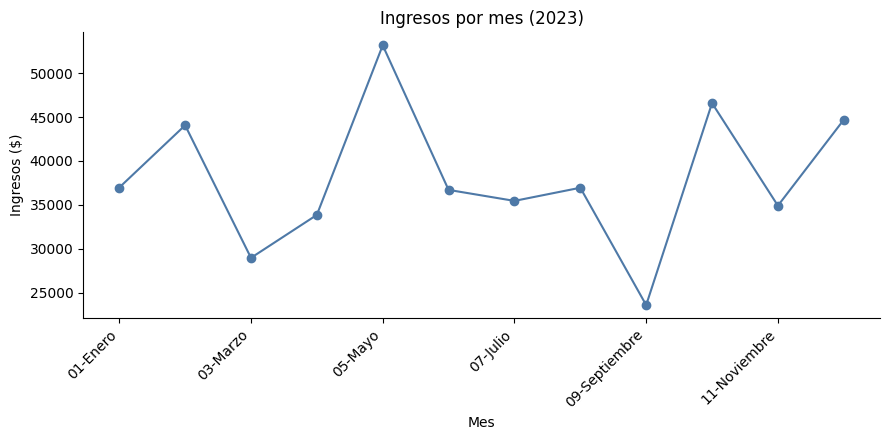

Mejor mes: 05-Mayo ($53,150)
Peor mes : 09-Septiembre ($23,620)


In [7]:
# B.2 — Tarea 1: Tendencia mensual de ingresos (líneas)
serie = df.groupby("NombreMes")["Total Amount"].sum().sort_index()
ax = serie.plot(marker="o", color="#4E79A7")
ax.set_title("Ingresos por mes (2023)")
ax.set_xlabel("Mes"); ax.set_ylabel("Ingresos ($)")
plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()
print("Mejor mes:", serie.idxmax(), f"(${serie.max():,.0f})")
print("Peor mes :", serie.idxmin(), f"(${serie.min():,.0f})")

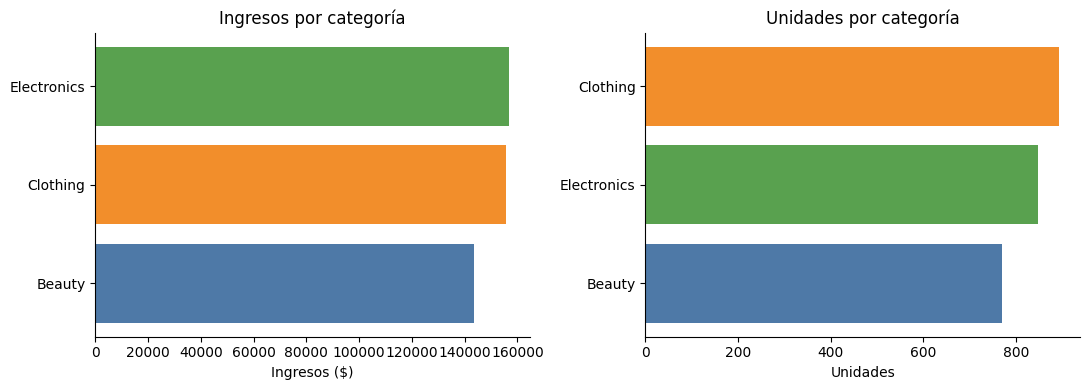

                  Ingresos  Unidades
Product Category                    
Beauty              143515       771
Clothing            155580       894
Electronics         156905       849


In [8]:
# B.3 — Tarea 2: Ingresos y unidades por categoría (barras ordenadas)
cat = df.groupby("Product Category").agg(Ingresos=("Total Amount","sum"),
                                         Unidades=("Quantity","sum")).sort_values("Ingresos")
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11,4))
a1.barh(cat.index, cat["Ingresos"], color=[PALETA[c] for c in cat.index])
a1.set_title("Ingresos por categoría"); a1.set_xlabel("Ingresos ($)")
unid = cat.sort_values("Unidades")
a2.barh(unid.index, unid["Unidades"], color=[PALETA[c] for c in unid.index])
a2.set_title("Unidades por categoría"); a2.set_xlabel("Unidades")
plt.tight_layout(); plt.show()
print(cat)

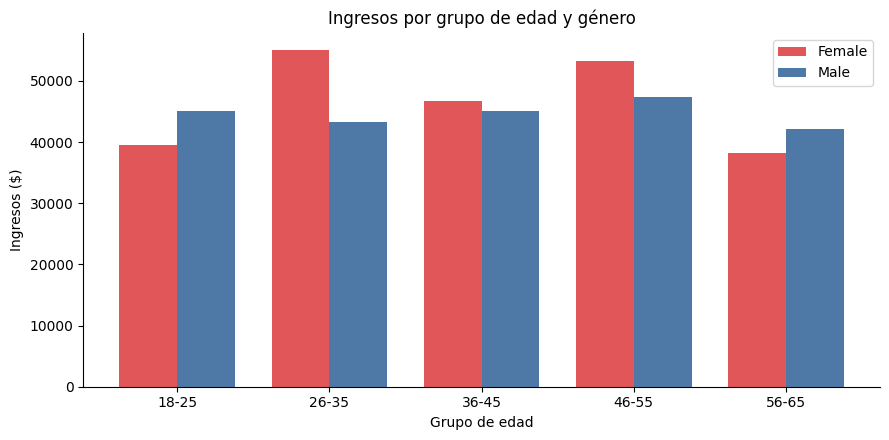

Gender     Female   Male
GrupoEdad               
18-25       39470  45080
26-35       55115  43365
36-45       46735  45135
46-55       53310  47380
56-65       38210  42200


In [9]:
# B.4 — Tarea 3: Perfil demográfico, ingresos por grupo de edad x género (barras agrupadas)
import numpy as np
piv = df.pivot_table(index="GrupoEdad", columns="Gender", values="Total Amount",
                     aggfunc="sum").reindex(["18-25","26-35","36-45","46-55","56-65"])
x = np.arange(len(piv.index)); w = 0.38
fig, ax = plt.subplots(figsize=(9,4.5))
ax.bar(x - w/2, piv["Female"], w, label="Female", color="#E15759")
ax.bar(x + w/2, piv["Male"],   w, label="Male",   color="#4E79A7")
ax.set_xticks(x); ax.set_xticklabels(piv.index)
ax.set_title("Ingresos por grupo de edad y género")
ax.set_xlabel("Grupo de edad"); ax.set_ylabel("Ingresos ($)"); ax.legend()
plt.tight_layout(); plt.show()
print(piv)

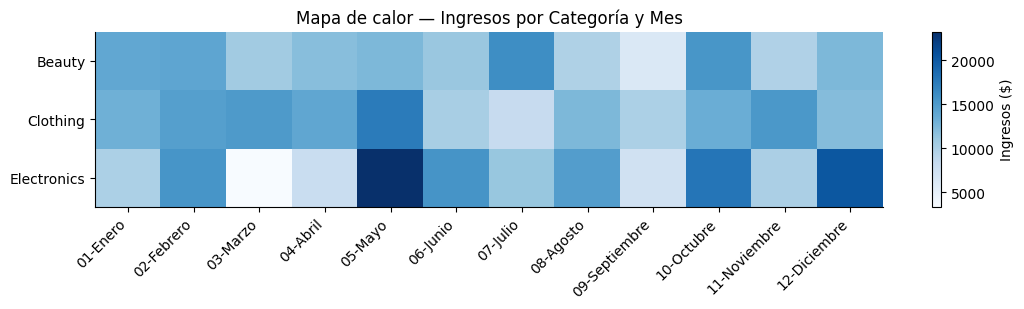

In [10]:
# B.5 — Mapa de calor: Categoría x Mes (ingresos)
mat = df.pivot_table(index="Product Category", columns="NombreMes",
                     values="Total Amount", aggfunc="sum")
fig, ax = plt.subplots(figsize=(11,3.2))
im = ax.imshow(mat.values, cmap="Blues", aspect="auto")
ax.set_xticks(range(len(mat.columns))); ax.set_xticklabels(mat.columns, rotation=45, ha="right")
ax.set_yticks(range(len(mat.index)));  ax.set_yticklabels(mat.index)
ax.set_title("Mapa de calor — Ingresos por Categoría y Mes")
fig.colorbar(im, ax=ax, label="Ingresos ($)")
plt.tight_layout(); plt.show()

<a id="anexoC"></a>
# Anexo C — Guía paso a paso para construir el dashboard en Tableau

Sigue esta guía para reproducir el dashboard. Cada worksheet corresponde a una vista justificada
en la [Fase 4](#fase4).

## C.0 — Importar el extracto `.hyper`
1. Abre **Tableau Desktop** (o Public).
2. Panel **Connect → To a File → More…** y selecciona **`retail_sales.hyper`**
   *(si aparece la opción “Tableau Hyper”, úsala)*.
3. En el panel de origen verás el esquema **`Extract`** con la tabla **`Ventas`**.
   **Arrástrala** al lienzo. Ya puedes ir a una hoja (**Sheet 1**).
4. **Verifica roles de campos** en el panel de datos:
   - **Dimensiones** (categóricas/temporales): `Date, NombreMes, Trimestre, DiaSemana, TipoDia,
     Product Category, Gender, GrupoEdad, NivelPrecio, Customer ID, Transaction ID, Anio, Mes`.
   - **Medidas** (numéricas a agregar): `Total Amount, Quantity, Price per Unit, Age`.
   - Si `Mes`, `Anio` o `Transaction ID` aparecen como **medida**, haz clic derecho →
     **Convert to Dimension** (son identificadores/ordinales, no se suman).

> **Nota:** si prefieres, también puedes conectar el `retail_sales_clean.csv`; el `.hyper` es lo
> pedido porque es el formato nativo y carga más rápido.

## C.1 — Worksheet **“KPIs”** (Vista 1)
- Crea 4 hojas o usa 4 *text marks*. Para cada KPI: arrastra la medida a **Text** en *Marks*.
  - **Ingresos totales:** `SUM(Total Amount)`.
  - **Transacciones:** `CNT(Transaction ID)` (o `COUNT`).
  - **Ticket promedio:** crea campo calculado `Ticket promedio = SUM([Total Amount]) / COUNTD([Transaction ID])`.
  - **Unidades:** `SUM(Quantity)`.
- Tipo de marca: **Text**. Da formato grande y agrega un título corto a cada hoja.

## C.2 — Worksheet **“Tendencia mensual”** (Vista 2 — líneas)
- **Columnas:** `NombreMes` (dimensión, queda ordenado por el prefijo 01..12).
- **Filas:** `SUM(Total Amount)`.
- **Marks → tipo:** **Line**. Activa **marcadores** (puntos).
- *(Opcional)* arrastra **`Product Category`** a **Color** para ver 3 líneas (una por categoría).
- Ordena el eje por mes; añade título “Ingresos por mes (2023)”.

## C.3 — Worksheet **“Ingresos por categoría”** (Vista 3 — barras ordenadas)
- **Columnas:** `SUM(Total Amount)`. **Filas:** `Product Category`.
- **Marks → tipo:** **Bar**.
- `Product Category` también a **Color** (paleta **Tableau 10**).
- **Ordena descendente** por `SUM(Total Amount)` (botón de *sort* en la barra de herramientas).
- Activa etiquetas (**Label**) para mostrar el valor.

## C.4 — Worksheet **“Perfil demográfico”** (Vista 4 — barras agrupadas)
- **Columnas:** `GrupoEdad`  →  luego arrastra **`Gender`** junto a `GrupoEdad` en *Columns*
  (esto crea las barras **agrupadas** lado a lado).
- **Filas:** `SUM(Total Amount)`.
- **Marks → tipo:** **Bar**; arrastra **`Gender`** a **Color** (2 tonos).
- Título: “Ingresos por grupo de edad y género”.

## C.5 — Worksheet **“Mapa de calor Categoría × Mes”** (Vista 5 — highlight table)
- **Columnas:** `NombreMes`. **Filas:** `Product Category`.
- **Marks → tipo:** **Square** (cuadro).
- Arrastra **`SUM(Total Amount)`** a **Color** → elige una paleta **secuencial** (p. ej. *Blue*).
- *(Opcional)* `SUM(Total Amount)` también a **Label** para ver los valores.

## C.6 — Armar el **Dashboard**
1. **Dashboard → New Dashboard.** Tamaño fijo o automático.
2. Arrastra las hojas: arriba la fila de **KPIs**; debajo, a la izquierda **Tendencia mensual**,
   a la derecha **Ingresos por categoría**; en una segunda fila **Perfil demográfico** y
   **Mapa de calor**.
3. **Filtros interactivos:** en una hoja, clic derecho sobre `Trimestre`, `Gender` y
   `Product Category` → **Show Filter**. Luego, en el filtro → **Apply to Worksheets →
   All Using This Data Source** para que afecten a todo el dashboard.
4. **Filter actions (opcional):** Dashboard → Actions → *Add Action → Filter* (p. ej. clic en una
   categoría filtra las demás vistas).

## C.7 — Dónde poner **“Grupo 2” e integrantes** (requisito de las Fases 1 y 2)
- Arrastra un objeto **Text** a la parte superior del dashboard y escribe el **título**:
  > **Análisis Visual de Ventas Minoristas 2023**
- Arrastra **otro objeto Text** (o usa el subtítulo) con:
  > **Grupo 2 — Ángel Espín & Carlos Ramírez**
- Opcionalmente añade en el pie (otro Text) la fuente:
  > *Fuente: Retail Sales Dataset (Kaggle). Datos sintéticos, 2023.*

## C.8 — Guardar / Publicar
- **Guardar empaquetado:** *File → Save As… → Tableau Packaged Workbook (`.twbx`)* — incluye el
  `.hyper` dentro, ideal para entregar.
- **Tableau Public:** *Server → Tableau Public → Save to Tableau Public As…* y comparte el enlace.

---

### Checklist de cumplimiento de la consigna
- [x] **Fase 1:** objetivo, equipo (Grupo 2, 2 personas) y datos públicos (Kaggle) — documentado.
- [x] **Fase 2:** título, integrantes, problema/solución, datos+atributos, preprocesamiento,
      escenario de uso narrativo y referencias — documentado.
- [x] **Fase 3:** tipo y cardinalidad del dataset; tipo/cardinalidad/rango por atributo; originales
      vs derivados; **3 tareas abstractas** con **6 atributos** — documentado.
- [x] **Fase 4:** justificación de marcas y canales por vista, con comparación de alternativas y
      decisiones de color — documentado.
- [x] **Implementación:** dashboard en **Tableau** sobre extracto **`.hyper`** (sin backend ni DB externa).
